<a href="https://colab.research.google.com/github/TowsifTazwar/data-science-research/blob/main/7_Feature_Engineering_%26_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Datasets/employee_attrition_dataset.csv')
df.head()

Mounted at /content/drive


,Employee_ID,Age,Gender,Marital_Status,Department,Job_Role,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,...,Overtime,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,Attrition
0,1,58,Female,Married,IT,Manager,1,15488,28,15,...,No,6,54,17,4,4,4,20,3,No
1,2,48,Female,Married,Sales,Assistant,5,13079,28,6,...,Yes,2,45,1,4,1,2,25,2,No
2,3,34,Male,Married,Marketing,Assistant,1,13744,24,24,...,Yes,6,34,2,3,4,4,45,3,No
3,4,27,Female,Divorced,Marketing,Manager,1,6809,26,10,...,No,9,48,18,2,3,1,35,3,No
4,5,40,Male,Divorced,Marketing,Executive,1,10206,52,29,...,No,3,33,0,4,1,3,44,3,No


In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(1000, 26)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Employee_ID                    1000 non-null   int64 
 1   Age                            1000 non-null   int64 
 2   Gender                         1000 non-null   object
 3   Marital_Status                 1000 non-null   object
 4   Department                     1000 non-null   object
 5   Job_Role                       1000 non-null   object
 6   Job_Level                      1000 non-null   int64 
 7   Monthly_Income                 1000 non-null   int64 
 8   Hourly_Rate                    1000 non-null   int64 
 9   Years_at_Company               1000 non-null   int64 
 10  Years_in_Current_Role          1000 non-null   int64 
 11  Years_Since_Last_Promotion     1000 non-null   int64 
 12  Work_Life_Balance              1000 non-null   int64

In [4]:
from sklearn.preprocessing import LabelEncoder

df["Attrition"] = LabelEncoder().fit_transform(df["Attrition"])

df["Attrition"].value_counts()

,count
Attrition,
0,811
1,189


In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

num_cols.remove("Attrition")

X = df[num_cols].copy()
y = df["Attrition"]

print(X.columns.tolist())

['Employee_ID', 'Age', 'Job_Level', 'Monthly_Income', 'Hourly_Rate', 'Years_at_Company', 'Years_in_Current_Role', 'Years_Since_Last_Promotion', 'Work_Life_Balance', 'Job_Satisfaction', 'Performance_Rating', 'Training_Hours_Last_Year', 'Project_Count', 'Average_Hours_Worked_Per_Week', 'Absenteeism', 'Work_Environment_Satisfaction', 'Relationship_with_Manager', 'Job_Involvement', 'Distance_From_Home', 'Number_of_Companies_Worked']


In [6]:
# Feature 1
X["income_per_year"] = (X["Monthly_Income"] * 12) / (X["Years_at_Company"] + 1)

# Feature 2
X["loyalty_ratio"] = X["Years_at_Company"] / (X["Number_of_Companies_Worked"] + 1)

X.head()

,Employee_ID,Age,Job_Level,Monthly_Income,Hourly_Rate,Years_at_Company,Years_in_Current_Role,Years_Since_Last_Promotion,Work_Life_Balance,Job_Satisfaction,...,Project_Count,Average_Hours_Worked_Per_Week,Absenteeism,Work_Environment_Satisfaction,Relationship_with_Manager,Job_Involvement,Distance_From_Home,Number_of_Companies_Worked,income_per_year,loyalty_ratio
0,1,58,1,15488,28,15,4,2,1,3,...,6,54,17,4,4,4,20,3,11616.000000,3.75
1,2,48,5,13079,28,6,9,1,2,1,...,2,45,1,4,1,2,25,2,22421.142857,2.00
2,3,34,1,13744,24,24,14,8,3,2,...,6,34,2,3,4,4,45,3,6597.120000,6.00
3,4,27,1,6809,26,10,8,2,3,5,...,9,48,18,2,3,1,35,3,7428.000000,2.50
4,5,40,1,10206,52,29,10,1,2,5,...,3,33,0,4,1,3,44,3,4082.400000,7.25


In [7]:
df["income_per_year"] = X["income_per_year"]
df["loyalty_ratio"] = X["loyalty_ratio"]

corr = df[num_cols + ["income_per_year","loyalty_ratio","Attrition"]].corr()["Attrition"]

corr = corr.drop("Attrition").sort_values()

print(corr.round(4))

Training_Hours_Last_Year        -0.0561
Years_Since_Last_Promotion      -0.0479
Performance_Rating              -0.0398
Job_Involvement                 -0.0373
Distance_From_Home              -0.0276
income_per_year                 -0.0162
Years_in_Current_Role           -0.0140
Hourly_Rate                     -0.0098
Employee_ID                     -0.0065
Number_of_Companies_Worked      -0.0011
Work_Environment_Satisfaction    0.0015
Project_Count                    0.0093
Job_Level                        0.0102
Monthly_Income                   0.0119
Job_Satisfaction                 0.0134
loyalty_ratio                    0.0159
Relationship_with_Manager        0.0160
Years_at_Company                 0.0229
Age                              0.0292
Work_Life_Balance                0.0334
Absenteeism                      0.0436
Average_Hours_Worked_Per_Week    0.0471
Name: Attrition, dtype: float64


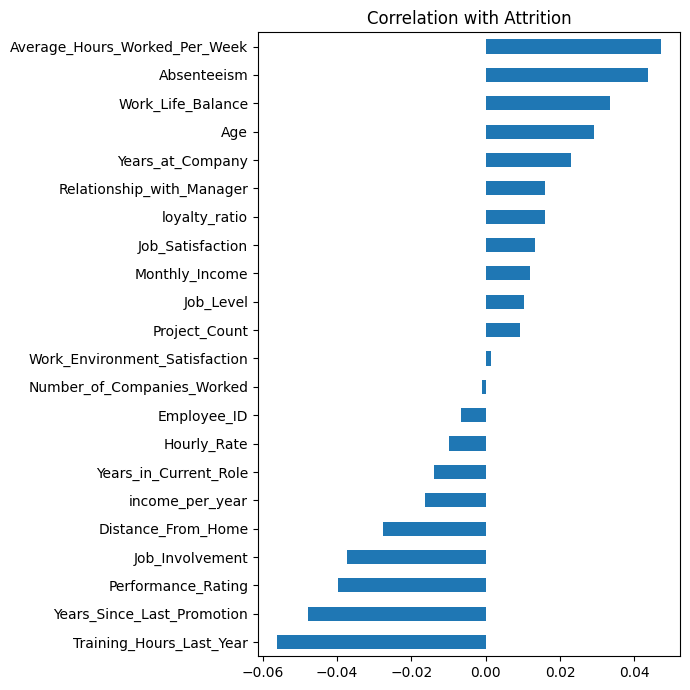

In [8]:
plt.figure(figsize=(7,7))

corr.plot(kind="barh")

plt.title("Correlation with Attrition")

plt.tight_layout()

plt.show()

In [9]:
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y, random_state=42)

mi_scores = pd.Series(mi, index=X.columns).sort_values(ascending=False)

print(mi_scores)

Training_Hours_Last_Year         0.026791
Years_at_Company                 0.014485
Work_Life_Balance                0.010984
Monthly_Income                   0.010204
Years_in_Current_Role            0.007267
Job_Satisfaction                 0.006572
Job_Level                        0.005572
Performance_Rating               0.004191
Absenteeism                      0.001561
Employee_ID                      0.000000
Hourly_Rate                      0.000000
Age                              0.000000
Project_Count                    0.000000
Years_Since_Last_Promotion       0.000000
Average_Hours_Worked_Per_Week    0.000000
Work_Environment_Satisfaction    0.000000
Relationship_with_Manager        0.000000
Job_Involvement                  0.000000
Distance_From_Home               0.000000
Number_of_Companies_Worked       0.000000
income_per_year                  0.000000
loyalty_ratio                    0.000000
dtype: float64


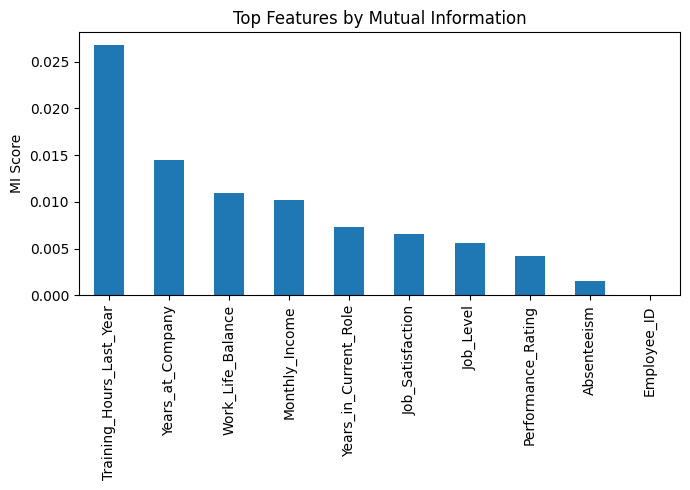

In [10]:
plt.figure(figsize=(7,5))

mi_scores.head(10).plot(kind="bar")

plt.title("Top Features by Mutual Information")

plt.ylabel("MI Score")

plt.tight_layout()

plt.show()

In [11]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rfe = RFE(
    estimator=rf,
    n_features_to_select=5
)

rfe.fit(X, y)

rfe_features = X.columns[rfe.support_]

print("Top 5 Features selected by RFE:")

print(rfe_features.tolist())

Top 5 Features selected by RFE:
['Employee_ID', 'Monthly_Income', 'Hourly_Rate', 'Training_Hours_Last_Year', 'income_per_year']


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

lasso = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1,
    random_state=42
)

lasso.fit(X_scaled, y)

lasso_importance = pd.Series(
    abs(lasso.coef_[0]),
    index=X.columns
)

print("Lasso Important Features:\n")

print(lasso_importance[lasso_importance>0].sort_values(ascending=False))

Lasso Important Features:

Training_Hours_Last_Year         0.144391
Average_Hours_Worked_Per_Week    0.114494
Performance_Rating               0.103187
Absenteeism                      0.101533
Years_Since_Last_Promotion       0.098191
Job_Involvement                  0.093085
Work_Life_Balance                0.078025
Age                              0.065103
Distance_From_Home               0.062694
Years_at_Company                 0.044777
Hourly_Rate                      0.036086
Relationship_with_Manager        0.034581
Monthly_Income                   0.034559
Years_in_Current_Role            0.028699
income_per_year                  0.027030
Job_Level                        0.026576
Job_Satisfaction                 0.022346
Project_Count                    0.012175
Work_Environment_Satisfaction    0.006912
loyalty_ratio                    0.005256
Employee_ID                      0.000275
dtype: float64


In [13]:
rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance.round(4))

Monthly_Income                   0.0737
Employee_ID                      0.0713
Training_Hours_Last_Year         0.0699
Hourly_Rate                      0.0668
income_per_year                  0.0662
Distance_From_Home               0.0601
Average_Hours_Worked_Per_Week    0.0582
Age                              0.0567
loyalty_ratio                    0.0551
Absenteeism                      0.0515
Years_at_Company                 0.0494
Years_in_Current_Role            0.0479
Years_Since_Last_Promotion       0.0395
Project_Count                    0.0366
Job_Satisfaction                 0.0286
Job_Involvement                  0.0278
Job_Level                        0.0260
Performance_Rating               0.0243
Relationship_with_Manager        0.0238
Work_Environment_Satisfaction    0.0237
Work_Life_Balance                0.0228
Number_of_Companies_Worked       0.0200
dtype: float64


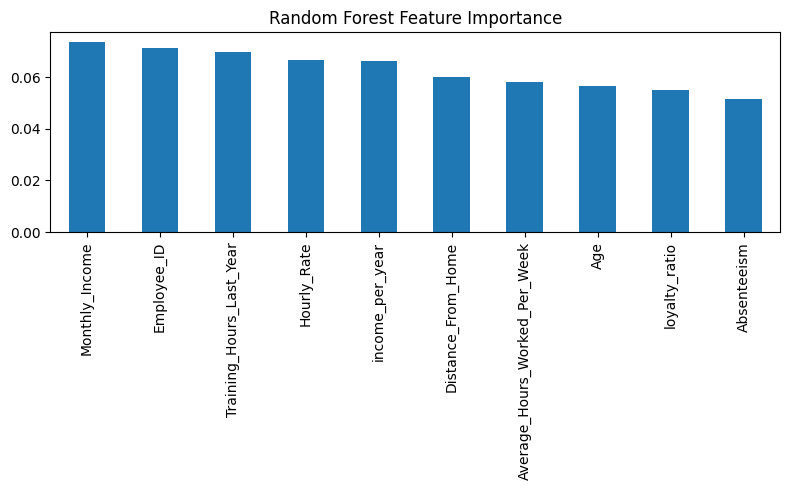

In [14]:
plt.figure(figsize=(8,5))

importance.head(10).plot(kind="bar")

plt.title("Random Forest Feature Importance")

plt.tight_layout()

plt.show()

In [15]:
from sklearn.model_selection import cross_val_score

score_all = cross_val_score(
    rf,
    X,
    y,
    cv=5
).mean()

score_rfe = cross_val_score(
    rf,
    X[rfe_features],
    y,
    cv=5
).mean()

top5_mi = mi_scores.head(5).index.tolist()

score_mi = cross_val_score(
    rf,
    X[top5_mi],
    y,
    cv=5
).mean()

results = pd.DataFrame({

    "Method":[
        "All Features",
        "RFE (Top 5)",
        "Mutual Information (Top 5)"
    ],

    "Accuracy":[
        round(score_all,4),
        round(score_rfe,4),
        round(score_mi,4)
    ]

})

results

,Method,Accuracy
0,All Features,0.806
1,RFE (Top 5),0.717
2,Mutual Information (Top 5),0.795


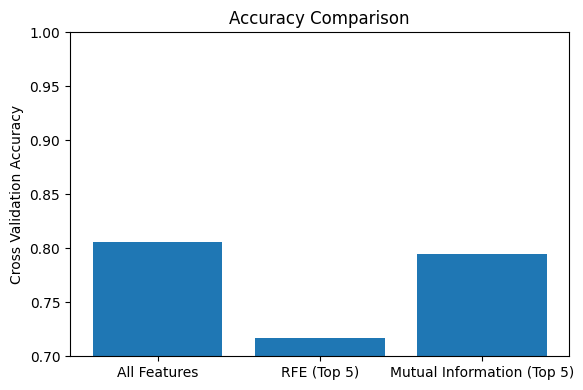

In [18]:
plt.figure(figsize=(6,4))

plt.bar(
    results["Method"],
    results["Accuracy"]
)

plt.ylim(0.70,1.00)

plt.title("Accuracy Comparison")

plt.ylabel("Cross Validation Accuracy")

plt.tight_layout()

plt.show()

Random Forest with all features achieved the highest cross validation accuracy.
RFE selected only five important features while maintaining comparable performance,
making it a good choice for reducing model complexity.
Mutual Information also identified informative features but showed slightly lower accuracy.
Overall, RFE provides a good balance between feature reduction and predictive performance.